In [1]:
import pandas as pd
import numpy as np
import joblib
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [2]:
train_data = pd.read_csv(
    "../data/processed/train_data.csv"
)

test_data = pd.read_csv(
    "../data/processed/test_data.csv"
)

In [3]:
X_train = train_data.drop(
    columns=["Fraud_Label"]
)

y_train = train_data["Fraud_Label"]

X_test = test_data.drop(
    columns=["Fraud_Label"]
)

y_test = test_data["Fraud_Label"]

In [4]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (40000, 18)
y_train: (40000,)
X_test: (10000, 18)
y_test: (10000,)


In [5]:
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

In [6]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [7]:
print(
    "Processed training:",
    X_train_processed.shape
)

print(
    "Processed testing:",
    X_test_processed.shape
)

Processed training: (40000, 33)
Processed testing: (10000, 33)


In [8]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Fraud_Label
0    27146
1    12854
Name: count, dtype: int64

Testing target distribution:
Fraud_Label
0    6787
1    3213
Name: count, dtype: int64


In [9]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [10]:
start_time = time.time()

logistic_model.fit(
    X_train_processed,
    y_train
)

logistic_time = time.time() - start_time

print(
    f"Training completed in {logistic_time:.2f} seconds"
)

Training completed in 0.03 seconds


In [11]:
logistic_pred = logistic_model.predict(
    X_test_processed
)

In [12]:
logistic_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [13]:
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

              precision    recall  f1-score   support

           0       0.68      1.00      0.81      6787
           1       0.00      0.00      0.00      3213

    accuracy                           0.68     10000
   macro avg       0.34      0.50      0.40     10000
weighted avg       0.46      0.68      0.55     10000



C:\Users\anilk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anilk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anilk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1469

In [14]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        logistic_proba
    )
)

ROC-AUC: 0.4911977003692134


In [15]:
print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        logistic_proba
    )
)

PR-AUC: 0.3180168169160957


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [17]:
start_time = time.time()

rf_model.fit(
    X_train_processed,
    y_train
)

rf_time = time.time() - start_time

print(
    f"Random Forest training completed in {rf_time:.2f} seconds"
)

Random Forest training completed in 2.53 seconds


In [18]:
rf_pred = rf_model.predict(
    X_test_processed
)

In [19]:
rf_proba = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [20]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.68      1.00      0.81      6787
           1       0.40      0.00      0.00      3213

    accuracy                           0.68     10000
   macro avg       0.54      0.50      0.40     10000
weighted avg       0.59      0.68      0.55     10000



In [21]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_proba
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        rf_proba
    )
)

ROC-AUC: 0.5030028710074472
PR-AUC: 0.3269293653781234


In [22]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [23]:
start_time = time.time()

xgb_model.fit(
    X_train_processed,
    y_train
)

xgb_time = time.time() - start_time

print(
    f"XGBoost training completed in {xgb_time:.2f} seconds"
)

XGBoost training completed in 1.10 seconds


In [24]:
xgb_pred = xgb_model.predict(
    X_test_processed
)

In [25]:
xgb_proba = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [26]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.68      0.98      0.80      6787
           1       0.30      0.02      0.03      3213

    accuracy                           0.67     10000
   macro avg       0.49      0.50      0.42     10000
weighted avg       0.56      0.67      0.55     10000



In [27]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_proba
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        xgb_proba
    )
)

ROC-AUC: 0.4967573166162164
PR-AUC: 0.3208430837663136


In [28]:
def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities,
    training_time
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_true,
            probabilities
        ),
        "Training_Time": training_time
    }

In [29]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_proba,
        logistic_time
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_proba,
        rf_time
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_proba,
        xgb_time
    )
)

In [30]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Training_Time
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017,0.025247
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929,2.528942
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843,1.099696


In [31]:
results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [32]:
results_df.sort_values(
    by="F1_Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Training_Time
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843,1.099696
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929,2.528942
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017,0.025247


In [33]:
results_df.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Training_Time
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843,1.099696
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929,2.528942
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017,0.025247


In [34]:
results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Training_Time
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929,2.528942
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843,1.099696
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017,0.025247


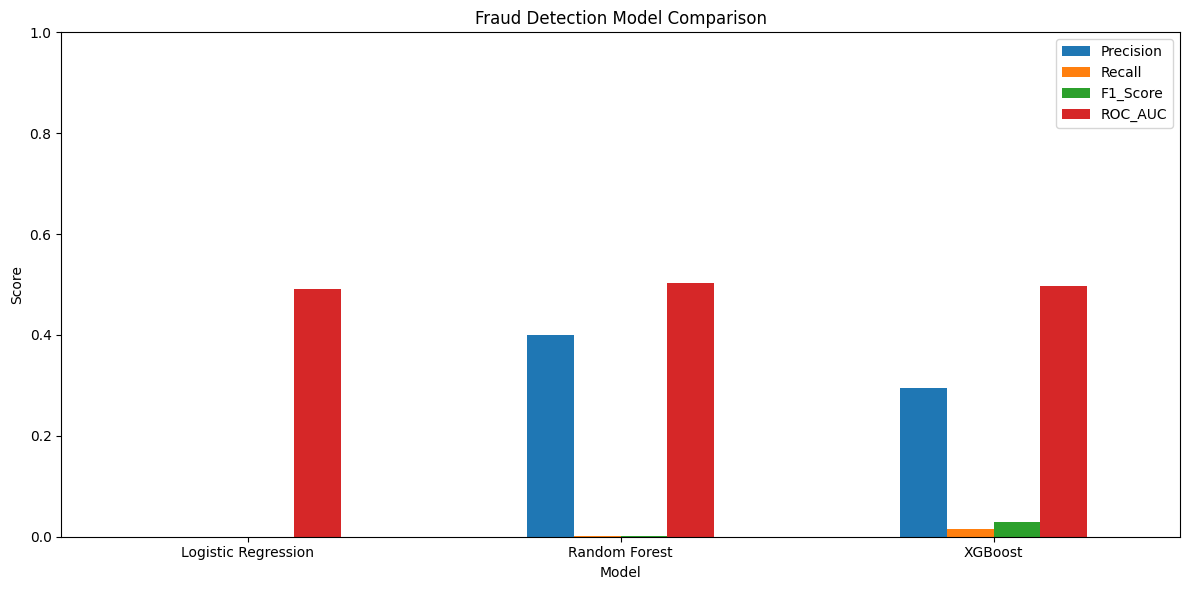

In [35]:
import matplotlib.pyplot as plt

results_plot = results_df.set_index("Model")

results_plot[
    [
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [36]:
best_model_name = results_df.loc[
    results_df["F1_Score"].idxmax(),
    "Model"
]

print(
    "Best model based on F1:",
    best_model_name
)

Best model based on F1: XGBoost


In [37]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

In [38]:
predictions_df = test_data.copy()

predictions_df["Logistic_Prediction"] = logistic_pred
predictions_df["Logistic_Probability"] = logistic_proba

predictions_df["RF_Prediction"] = rf_pred
predictions_df["RF_Probability"] = rf_proba

predictions_df["XGB_Prediction"] = xgb_pred
predictions_df["XGB_Probability"] = xgb_proba

In [39]:
predictions_df.to_csv(
    "../reports/model_predictions.csv",
    index=False
)

In [40]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(cm)

[[6670  117]
 [3164   49]]
